In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

import openturns as ot
import openturns.viewer as otv
ot.Log.Show(ot.Log.NONE)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


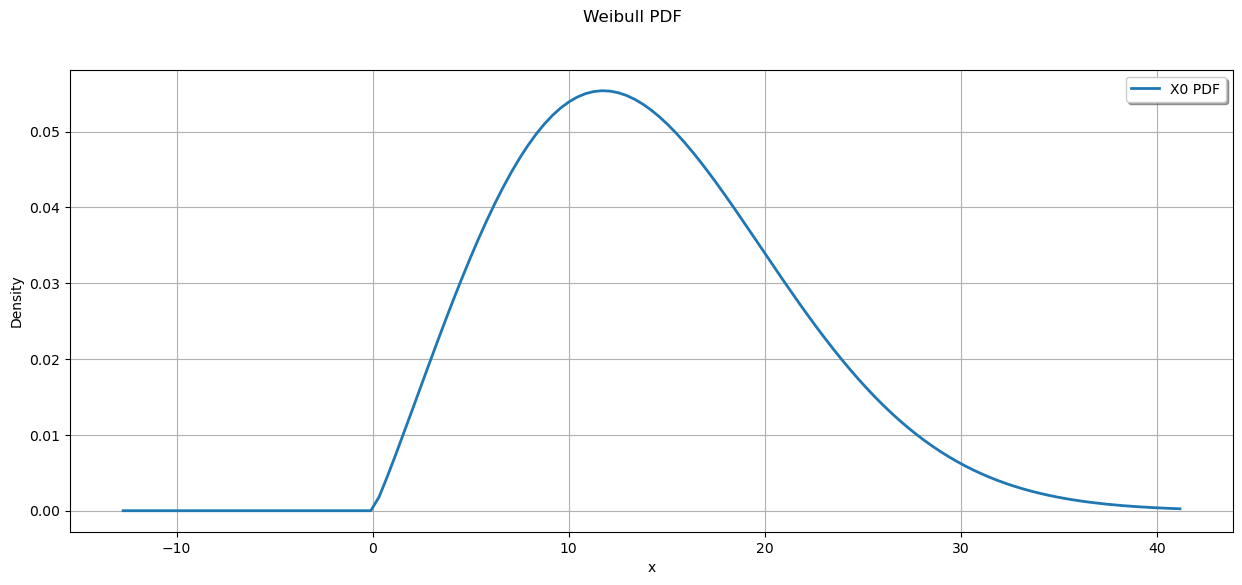

In [5]:
U10 = ot.WeibullMin(16, 2.1)
d = ot.Normal(-2, 0.3)
X1 = U10
X2 = d 
x = (X1, X2)

# graph = U10.drawPDF()
# graph.setTitle("Weibull PDF")
# graph.setXTitle("x")
# graph.setYTitle("Density")

view = otv.View(graph)

In [6]:
#constants
F = 35430
g = 9.81
Rc = 0.5

gamma_b = 1
gamma_f = 1 
gamma_s = 1 # gamma_beta
gamma_n = 1 # gamma_nu
gamma = gamma_b * gamma_f * gamma_s * gamma_n

tan_a = 1/3.3

global F 
global g
global Rc
global gamma
global gamma_b
global tan_a


In [7]:
#functions
def dF_tilde(x):
    # Parameters
    u10 = x[0]
    d = x[1]    

    # Terms
    F_tilde = (g*F)/(u10**2)
    d_tilde = (g*d)/(u10**2)

    return F_tilde, d_tilde

def H_tilde(x):
    # Parameters
    H_inf = 0.14 #constant

    F_tilde, d_tilde = dF_tilde(x)

    # Terms
    H_tilde_1 = np.tanh(0.343 * d_tilde**1.14)
    H_tilde_2 = np.tanh((4.41 * (10**-4) * (F_tilde**0.79)) / H_tilde_1)

    # Final calculation
    H_tilde = H_inf * (H_tilde_1 * H_tilde_2)**0.572

    return H_tilde

def T_tilde(x):
    # Parameters
    T_inf = 7.69 #constant

    F_tilde, d_tilde = dF_tilde(x)

    # Terms
    T_tilde_1 = np.tanh(0.10 * d_tilde**2.01)
    T_tilde_2 = np.tanh((2.77 * (10**-7) * (F_tilde**1.45)) / T_tilde_1)

    # Final calculation
    T_tilde = T_inf * (T_tilde_1 * T_tilde_2)**0.187

    return T_tilde

    


In [11]:
def LSF(x):
    # Parameters
    u = x[0]
    d = x[1]

    H = H_tilde(x) * (u**2 / g)
    T = T_tilde(x) * (u**2 / g)
    L_0 = (g * T**2) / (2 * np.pi)
    xi = tan_a / np.sqrt(H / L_0)

    q_max = 5

    # Main calculation
    term_1 = ((0.026 * gamma_b * xi) / np.sqrt(tan_a))
    term_2 = np.exp(-((2.5 * Rc) / (xi * H * gamma))**1.3)
    term_d = np.sqrt(g * H**3)

    q = term_1 * term_2 * term_d
    
    q_condition = q - q_max

In [13]:
print(LSF((40, 2)))

None
